# Estimation du prix de voitures d'occasion

Nous disposons d'un ensemble de données décrivant des voitures d'occasion, telles que marque, modèle, age, ainsi que leur prix de vente. A partir de données concernant un véhicule, nous souhaiterions pouvoir en prédire le prix de vente. Il s'agit d'un exemple de régression (apprentissage supervisé).

## Compréhension du métier

On essaye de déterminer si une approche basée sur le Machine Learning est appropriée

* Quel est ce problème ?
* Comment ce problème est-il traité aujourd'hui ?
* En quoi la solution actuelle doit-elle être améliorée ?
* Est-ce qu'une approche "classique" permettrait de le résoudre ?
* Quel est l'objectif à atteindre par la soultion ?
* Comment mesurer la valeur métier de la solution ?

## Compréhension des données

* De quelles données peut-on disposer?
* Les données sont-elles en quantité suffisante ?
* Les données sont-elles de qualité suffisante ?
* Peut-on trouver d'autres données ?
* Peut-on améliorer la qualité des données existantes ?
* Doit-on réviser les objectifs par rapport aux données dont on dispose ?

Le Dataset utilisé provient de [Kaggle](https://www.kaggle.com) et est accessible depuis https://www.kaggle.com/CooperUnion/cardataset

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

sns.set()
%matplotlib inline

In [9]:
car_prices = pd.read_csv("datasets/car-prices.csv")
car_prices.head(5)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


### Les données sont-elles en quantité suffisante ?

In [10]:
car_prices.shape

(11914, 16)

### Les données sont-elles de qualitité suffisante ?

#### Types de données et valeurs nulles

In [11]:
car_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

#### Statistiques

In [12]:
car_prices.describe().round(2)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.00,11845.00,11884.00,11908.00,11914.00,11914.00,11914.00,11914.00
mean,2010.38,249.39,5.63,3.44,26.64,19.73,1554.91,40594.74
std,7.58,109.19,1.78,0.88,8.86,8.99,1441.86,60109.10
min,1990.00,55.00,0.00,2.00,12.00,7.00,2.00,2000.00
25%,2007.00,170.00,4.00,2.00,22.00,16.00,549.00,21000.00
50%,2015.00,227.00,6.00,4.00,26.00,18.00,1385.00,29995.00
75%,2016.00,300.00,6.00,4.00,30.00,22.00,2009.00,42231.25
max,2017.00,1001.00,16.00,4.00,354.00,137.00,5657.00,2065902.00


### Distribution des valeurs de la variable à prédire

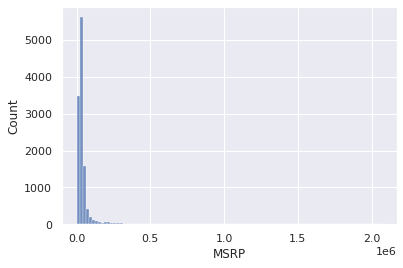

In [13]:
sns.histplot(car_prices["MSRP"], bins=100);

Les valeurs semblent très concentrées dans les prix les plus bas.

Observons d'abord en détail la partie haute (prix élevés).

<AxesSubplot:xlabel='MSRP', ylabel='Count'>

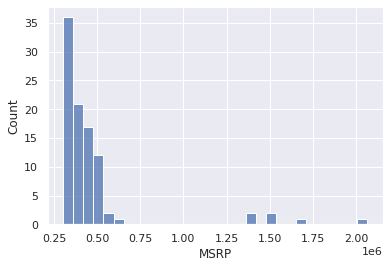

In [14]:
sns.histplot(car_prices.MSRP[car_prices.MSRP >= 300_000])

In [15]:
# De quelles marques s'agit-il ?
car_prices[car_prices["MSRP"] > 300_000]["Make"].unique()

array(['Maybach', 'Ferrari', 'Lamborghini', 'Bentley', 'Porsche',
       'Rolls-Royce', 'Lexus', 'Mercedes-Benz', 'Aston Martin', 'Bugatti'],
      dtype=object)

Puis les voitures plus économiques

<AxesSubplot:xlabel='MSRP', ylabel='Count'>

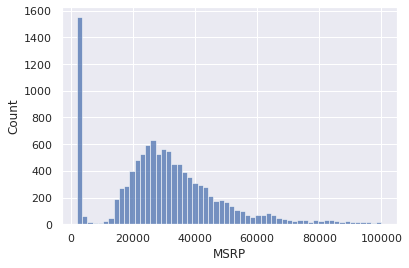

In [16]:
sns.histplot(car_prices.MSRP[car_prices.MSRP < 100_000])

Etant donné la forme de la courbe (allongée à droite), on peut envisager une conversion en log de la target

<AxesSubplot:xlabel='MSRP', ylabel='Count'>

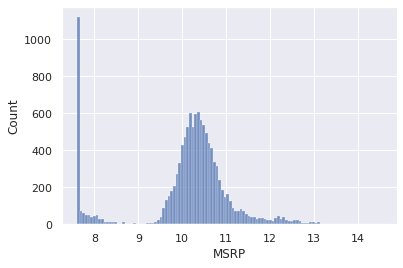

In [17]:
sns.histplot(np.log1p(car_prices.MSRP))

## Préparation des données

* Nettoyage des données
* Transformation des données
* Selection des données

### Sélection des variables

La plupart des algorithmes de Machine Learning ne savent traiter que les données numériques. Dans un premier temps, pour simplifier, nous ne conserverons donc que celles-ci.

### Traitement des données nulles

#### La variable Engine HP

On remplacera les valeurs manquantes par la médiane 

#### La variable Engine Cylinders

On remplacera les valeurs manquantes et nulles par la médiane 

#### La variable Number of Doors

Elle apparaît comme numérique, mais elle est en réalité catégorielle.

#### En pratique

In [18]:
num_cols = [
    'Year', 'Engine HP', 'Engine Cylinders',
    'highway MPG', 'city mpg', 'Popularity'
]

In [20]:
# Paramétrage du processus de modélisation

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

process_params = {
    "logarithm_target": False,
    "model": LinearRegression()
}

In [21]:
from sklearn.impute import SimpleImputer

def process_num_values(df):
    df = df[num_cols]
    df = df.replace(0, np.nan)
    X = SimpleImputer(strategy="median").fit_transform(df)  

    y = car_prices["MSRP"]
    
    return X, y

X, y = process_num_values(car_prices)
X.shape, y.shape

((11914, 6), (11914,))

Convsersion log si nécéssaire

In [30]:
if process_params["logarithm_target"]:
    y = np.log1p(y)

### Préparation des jeux d'apprentissage et de test

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

## Modélisation

* Choisir l'algorithme de Machine Learning à utiliser
* Choisir une métrique 

In [32]:
model = process_params["model"]
model.fit(X_train, y_train)

LinearRegression()

In [33]:
y_pred_train = model.predict(X_train)
y_pred = model.predict(X_test)

In [34]:
# Conversion inverse (exponentielle)

if process_params["logarithm_target"]:
    y_train = car_prices["MSRP"][y_train.index]
    y_test = car_prices["MSRP"][y_test.index]
    
    # On limite le prix max pour éviter les overflows
    max_log_y = y.max()
    y_pred[y_pred > max_log_y] = max_log_y
    y_pred_train[y_pred_train > max_log_y] = max_log_y

    y_pred = np.expm1(y_pred)
    y_pred_train = np.expm1(y_pred_train)

In [35]:
from sklearn.metrics import mean_squared_error

def root_mean_squared_error(y, y_pred):
    return np.sqrt(mean_squared_error(y, y_pred))

## Etude des erreurs

In [36]:
rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_test = root_mean_squared_error(y_test, y_pred)

rmse_train, rmse_test

(42801.3395077533, 49878.99690099804)

In [37]:
# erreur en pourcentage du prix

err_pct = np.abs(y_test - y_pred) / y_test

(0.0, 250.0)

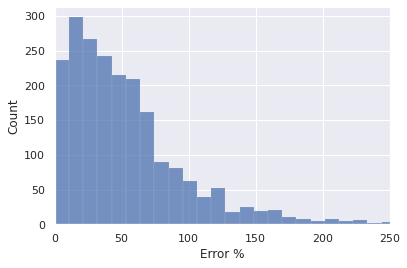

In [38]:
sns.histplot(err_pct * 100)
plt.xlabel("Error %")
plt.xlim(0, 250)

On essaye de comprendre quel est le profil des voitures qui ont une erreur élevée

In [39]:
high_error_cars = car_prices.loc[err_pct[err_pct > 0.2].index]
high_error_cars.shape

(1884, 16)

In [40]:
high_error_cars.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
5248,Hyundai,Genesis Coupe,2014,premium unleaded (recommended),274.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Midsize,Coupe,27,19,1439,27200
610,Ferrari,575M,2004,premium unleaded (required),515.0,12.0,MANUAL,rear wheel drive,2.0,"Exotic,High-Performance",Compact,Coupe,15,9,2774,217890
4673,Ford,Fiesta,2015,regular unleaded,120.0,4.0,MANUAL,front wheel drive,4.0,NaN,Compact,Sedan,36,28,5657,14455
8480,Suzuki,Reno,2007,regular unleaded,127.0,4.0,MANUAL,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,28,20,481,13599
4792,Ford,Focus,2017,flex-fuel (unleaded/E85),160.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,"Hatchback,Flex Fuel",Compact,4dr Hatchback,40,27,5657,21675


In [41]:
high_error_cars.describe().round(2)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,1884.00,1876.00,1880.00,1882.00,1884.00,1884.00,1884.00,1884.00
mean,2009.53,241.97,5.63,3.41,26.72,19.93,1539.61,38383.80
std,8.22,114.81,1.85,0.89,8.94,9.83,1388.51,72699.04
min,1990.00,63.00,0.00,2.00,12.00,8.00,2.00,2000.00
25%,2004.00,160.00,4.00,2.00,22.00,15.00,549.00,18158.75
50%,2014.00,208.00,6.00,4.00,26.00,18.00,1385.00,27522.00
75%,2016.00,295.00,6.00,4.00,31.00,22.00,2009.00,39035.00
max,2017.00,1001.00,16.00,4.00,111.00,137.00,5657.00,1705769.00


In [42]:
car_prices.describe().round(2)

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.00,11845.00,11884.00,11908.00,11914.00,11914.00,11914.00,11914.00
mean,2010.38,249.39,5.63,3.44,26.64,19.73,1554.91,40594.74
std,7.58,109.19,1.78,0.88,8.86,8.99,1441.86,60109.10
min,1990.00,55.00,0.00,2.00,12.00,7.00,2.00,2000.00
25%,2007.00,170.00,4.00,2.00,22.00,16.00,549.00,21000.00
50%,2015.00,227.00,6.00,4.00,26.00,18.00,1385.00,29995.00
75%,2016.00,300.00,6.00,4.00,30.00,22.00,2009.00,42231.25
max,2017.00,1001.00,16.00,4.00,354.00,137.00,5657.00,2065902.00


## Evaluation

On vérifie que le modèle répond bien au besoin

* Vérifier que la métrique métier atteint les objectifs fixés lors de la phase de compréhension du métier.
* Sinon, on itère en partant des pistes identifiées lors de l'itération courante